## Business Problem

The objective is not only to predict customer churn, but to quantify its financial impact and identify actionable strategies to improve customer retention.

This analysis focuses on identifying high-value customers at risk and understanding the key drivers behind churn.

In [2]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Ver primeras filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Loading

The dataset is loaded using pandas. This dataset contains customer information, service details, and churn status.

In [4]:
# Información general
df.info()

# Valores nulos
df.isnull().sum()

# Distribución de churn
df['Churn'].value_counts()

# Proporción de churn
df['Churn'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


No     0.73463
Yes    0.26537
Name: Churn, dtype: float64

## Exploratory Data Analysis (EDA)

Initial exploration of the dataset to understand data types, missing values, and the distribution of the target variable (Churn).

In [6]:
# Convertir a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Revisar nulos generados
df['TotalCharges'].isnull().sum()

11

In [7]:
df = df.dropna(subset=['TotalCharges'])
df['TotalCharges'].isnull().sum()

0

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


## Data Cleaning

The 'TotalCharges' column was converted to numeric format. Missing values were identified and removed to ensure data consistency for analysis and modeling.

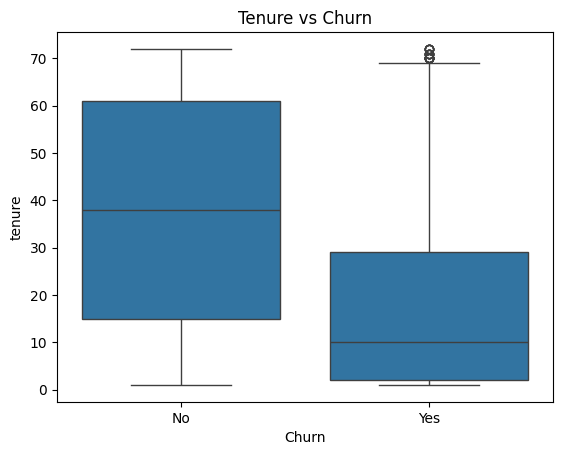

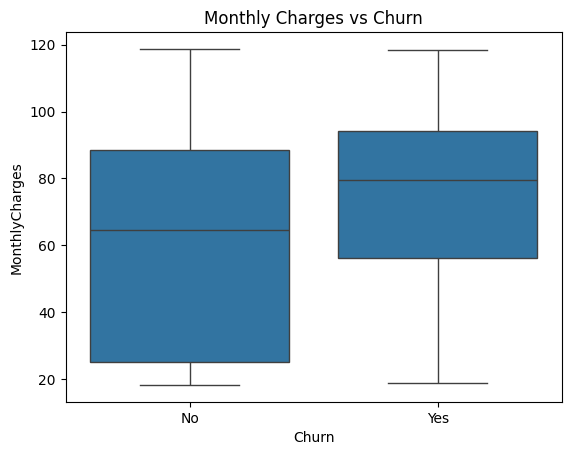

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

# MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

## Customer Behavior Analysis

Analyzing how tenure and monthly charges differ between customers who churned and those who stayed.

### Key Insight

Customers with higher monthly charges show a higher likelihood of churn.

This suggests that pricing may be a critical factor, but likely in combination with perceived value. High-paying customers may have higher expectations, leading to dissatisfaction and eventual churn.

This represents a potential opportunity for retention strategies focused on high-value customers.

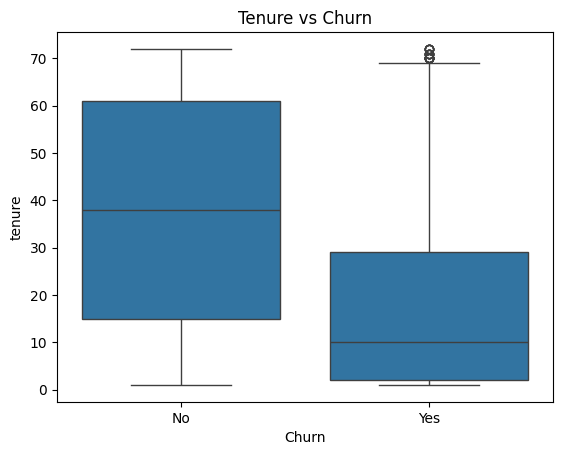

In [13]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

### Key Findings

- Customers who churn tend to have significantly lower tenure, indicating that most churn happens early in the customer lifecycle.
- Customers with higher monthly charges are more likely to churn.

### Business Interpretation

Churn is concentrated among new customers with higher monthly costs. This suggests a mismatch between customer expectations and perceived value early in the relationship.

### Recommendation

Retention strategies should focus on the first months of the customer lifecycle, especially for high-paying customers. Improving onboarding experience and perceived value could reduce churn.

In [15]:
# Copia de trabajo
df_model = df.copy()

# Convertir target a binario
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Eliminar ID (no aporta al modelo)
df_model = df_model.drop('customerID', axis=1)

df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Data Preparation for Modeling

Preparing dataset for machine learning by converting the target variable into binary format and removing non-informative features.

In [17]:
# One-hot encoding
df_model = pd.get_dummies(df_model, drop_first=True)

df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


Categorical variables were transformed using one-hot encoding to make the dataset suitable for machine learning models.

In [19]:
df_model.shape

(7032, 31)

In [20]:
from sklearn.model_selection import train_test_split

# Separar variables
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((5625, 30), (1407, 30))

## Train-Test Split

The dataset was split into training and testing sets to evaluate model performance on unseen data.

In [22]:
from sklearn.linear_model import LogisticRegression

# Crear modelo
model = LogisticRegression(max_iter=1000)

# Entrenar
model.fit(X_train, y_train)

C:\Users\polo6\anaconda3\envs\dataprep_env\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


A Logistic Regression model was used as a baseline to predict customer churn.

In [24]:
from sklearn.metrics import accuracy_score, classification_report

# Predicciones
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Reporte
print(classification_report(y_test, y_pred))

Accuracy: 0.7867803837953091
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Model Evaluation

The model achieved an accuracy of approximately 79%. However, a deeper analysis reveals an imbalance in performance:

- Recall for non-churn customers: 88%
- Recall for churn customers: 52%

This indicates that while the model performs well in identifying customers who stay, it struggles to detect customers at risk of leaving.

## Business Implication

In churn prediction, recall for the churn class is critical. Missing customers who are likely to leave represents lost opportunities for retention.

## Model Improvement Approach

To improve performance, techniques such as class balancing or more advanced models should be considered.

In [26]:
model = LogisticRegression(max_iter=3000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



### Model Comparison

The initial model showed limited ability to detect churn, with a recall of approximately 52% for churn cases.

After applying class weighting, recall increased significantly to around 80%, substantially improving the model's ability to identify customers at risk of leaving.

This improvement comes at the cost of reduced overall accuracy and precision, but represents a more practical solution for business applications.

In churn prediction, failing to identify a customer who is likely to leave is typically more costly than incorrectly flagging a customer who would stay. Therefore, prioritizing recall is a more effective strategy.

In [28]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coefficients.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,1.245944
8,MultipleLines_No phone service,0.515135
23,StreamingMovies_Yes,0.445927
21,StreamingTV_Yes,0.435998
7,PhoneService_Yes,0.351635
28,PaymentMethod_Electronic check,0.294114
9,MultipleLines_Yes,0.282536
0,SeniorCitizen,0.261075
26,PaperlessBilling_Yes,0.248027
17,DeviceProtection_Yes,0.061063


### Feature Interpretation

The model highlights several key factors associated with higher churn risk.

Customers with fiber optic internet service show a higher likelihood of churn, which may indicate higher expectations or service dissatisfaction in this segment.

Payment method also plays a significant role, with customers using electronic check exhibiting higher churn rates. This could be associated with less stable or more transactional customer relationships.

Senior citizens and customers with paperless billing are also more likely to churn, suggesting behavioral or demographic patterns that may influence retention.

Additionally, service-related features such as streaming services and multiple lines contribute to churn risk, indicating that more complex service bundles may increase the likelihood of dissatisfaction.

Overall, churn appears to be driven by a combination of customer profile, service type, and payment behavior, reinforcing the need for targeted retention strategies rather than a one-size-fits-all approach.

These findings are consistent with the patterns observed during exploratory data analysis, reinforcing the reliability of the model.

In [30]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

roc_auc

0.8317630493189972

### ROC AUC

The model achieves a ROC AUC score of approximately 0.83, indicating a good ability to distinguish between customers who churn and those who remain.

This suggests that the available features contain meaningful predictive signal, although the separation between classes is not perfect.

This level of performance is consistent with real-world churn prediction problems, where customer behavior is influenced by multiple factors and inherent variability.

### Final Conclusion

The final model provides a practical and business-oriented approach to churn prediction.

Results show that churn is primarily driven by a combination of short customer tenure, higher monthly charges, and contract type. In particular, customers in the early stages of their lifecycle and those on month-to-month contracts represent the highest risk segment.

From a business perspective, this enables targeted retention strategies focused on:

- Early-stage customer engagement  
- Retention programs for high-value customers  
- Incentives to promote long-term contracts  

By applying this model, the company can proactively identify customers at risk and take action before churn occurs, improving customer lifetime value and reducing revenue loss.